In [11]:
import os
os.environ["ANTHROPIC_API_KEY"] = "paste-your-key-here"
#!pip install anthropic
"""
I'm using manual inputs to demonstrate the logic but in prod we'd connect to live market data so Greeks reprice in real time.
"""

"\nI'm using manual inputs to demonstrate the logic but in prod we'd connect to live market data so Greeks reprice in real time.\n"

In [12]:
from scipy.stats import norm
import numpy as np

def BS_greeks(S, K, T, r, sigma, option_type='call'):
    """
    S = current spot price
    K = strike price
    T = time to expiry in years
    r = risk free rate
    sigma = implied volatility (e.g. 0.3 = 30%)
    option_type = 'call' or 'put'
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        delta = norm.cdf(d1)
    else:
        delta = norm.cdf(d1) - 1

    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega  = S * norm.pdf(d1) * np.sqrt(T) * 0.01  # per 1% vol move
    theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))) / 365  # per day

    return {
        "delta": round(delta, 4),
        "gamma": round(gamma, 4),
        "vega":  round(vega, 4),
        "theta": round(theta, 4)
    }

print("Black-Scholes Greeks function loaded")

Black-Scholes Greeks function loaded


In [13]:
from datetime import datetime
#input a new trade

spot_price    = 108.0   # Brent crude current price
strike_price  = 120.0   # OTM betting on further spike
implied_vol   = 0.55    # vol has exploded with iran sanctioning back 
risk_free_rate = 0.05
expiry_date   = "2026-06-30"
option_type   = "call"
position_size = 100
direction     = "long"    

today = datetime.today()
expiry = datetime.strptime(expiry_date, "%Y-%m-%d")
T = (expiry - today).days / 252 

print(f"Position: {direction} {position_size} {option_type} options")
print(f"Spot: ${spot_price} | Strike: ${strike_price} | Expiry: {expiry_date}")
print(f"Implied Vol: {implied_vol*100}% | Risk Free Rate: {risk_free_rate*100}%")
print(f"Time to expiry: {round(T, 4)} years ({(expiry - today).days} trading days)")

Position: long 100 call options
Spot: $108.0 | Strike: $120.0 | Expiry: 2026-06-30
Implied Vol: 55.00000000000001% | Risk Free Rate: 5.0%
Time to expiry: 0.3849 years (97 trading days)


In [14]:
# Calc Greeks
greeks = BS_greeks(
    S           = spot_price,
    K           = strike_price,
    T           = T,
    r           = risk_free_rate,
    sigma       = implied_vol,
    option_type = option_type
)

# Adjust for direction
multiplier = 1 if direction == "long" else -1

print("=== GREEKS ===")
print(f"Delta : {round(greeks['delta'] * multiplier, 3)}")
print(f"Gamma : {round(greeks['gamma'] * multiplier, 3)}")
print(f"Vega  : {round(greeks['vega']  * multiplier, 3)}")
print(f"Theta : {round(greeks['theta'] * multiplier, 3)}")

=== GREEKS ===
Delta : 0.467
Gamma : 0.011
Vega  : 0.266
Theta : -0.052


In [15]:
import anthropic
import json

def generate_risk_report(position_details, greeks, grid):
    
    client = anthropic.Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
    
    worst_key = min(grid, key=grid.get)
    best_key  = max(grid, key=grid.get)
    
    context = f"""
    I'm a risk analyst
    
    A trader wants to enter this position:
    - Asset: Crude Oil Options
    - Direction: {position_details['direction']}
    - Option type: {position_details['option_type']}
    - Position size: {position_details['size']} contracts
    - Spot price: ${position_details['spot']}
    - Strike price: ${position_details['strike']}
    - Expiry: {position_details['expiry']}
    - Implied volatility: {position_details['vol']*100}%
    
    The computed Greeks are:
    - Delta: {greeks['delta']}
    - Gamma: {greeks['gamma']}
    - Vega: {greeks['vega']}
    - Theta: {greeks['theta']}
    
    Stress test results (qrisklab StressTest, spot and vol shocks):
    - Worst case: spot {worst_key[0]:+.0%}, vol {worst_key[1]:+.0%} → P&L = ${grid[worst_key]:,.0f}
    - Best case:  spot {best_key[0]:+.0%}, vol {best_key[1]:+.0%} → P&L = ${grid[best_key]:,.0f}
    - Iran deal scenario (spot -20%, vol -30%): P&L = ${grid.get((-0.20, -0.30), 'N/A'):,.0f}
    - Escalation scenario (spot +20%, vol +10%): P&L = ${grid.get((0.20, 0.10), 'N/A'):,.0f}
    
    Write a concise plain English risk summary for the risk manager.
    Cover: directional risk, vol risk, time decay, and the stress scenarios above.
    Do not recompute or second guess the numbers above.
    Keep it to 4-5 bullet points.
    """
    
    message = client.messages.create(
        model="claude-sonnet-4-20250514",
        max_tokens=1000,
        messages=[{"role": "user", "content": context}]
    )
    
    return message.content[0].text

print("Risk report function loaded")

Risk report function loaded


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from qrisklab.core.stress_tests import StressTest

# Build position DataFrame in qrisklab format
df_pos = pd.DataFrame([{
    'spot':               spot_price,
    'strike':             strike_price,
    'vol':                implied_vol,
    'time_to_expiry':     T,
    'rate':               risk_free_rate,
    'cost_of_carry_rate': risk_free_rate,
    'put_call':           option_type,
    'quantity':           position_size * (1 if direction == 'long' else -1),
    'multiplier':         1,
    'vol_shock_mode':     'relative',
}])

# Run stress grid
spot_shocks = np.arange(-0.30, 0.31, 0.10)
vol_shocks  = np.arange(-0.30, 0.31, 0.10)

grid = {}
st = StressTest()

for ss in spot_shocks:
    for vs in vol_shocks:
        df_scenario = df_pos.copy()
        df_scenario['spot_shock'] = ss
        df_scenario['vol_shock']  = vs
        result = st.shock_df(df_scenario, 'pnl')
        grid[(round(ss, 2), round(vs, 2))] = round(result['pnl'].sum(), 2)

print("Stress grid computed")

Stress grid computed


In [17]:
# Package position details into a dictionary
position_details = {
    'direction':   direction,
    'option_type': option_type,
    'size':        position_size,
    'spot':        spot_price,
    'strike':      strike_price,
    'expiry':      expiry_date,
    'vol':         implied_vol
}

# Generate the risk report
print("=== LLM RISK REPORT ===")
print("Generating report...\n")

report = generate_risk_report(position_details, greeks, grid)
print(report)

print("\n=== RAW GREEKS ===")
print(f"Delta : {greeks['delta']}")
print(f"Gamma : {greeks['gamma']}")
print(f"Vega  : {greeks['vega']}")
print(f"Theta : {greeks['theta']}")

=== LLM RISK REPORT ===
Generating report...

**Risk Summary - Crude Oil Call Options Position**

• **Directional Risk**: This position benefits from rising oil prices with moderate sensitivity (Delta 0.47), meaning each $1 oil price increase generates roughly $47 profit per contract. The position loses money if oil stays flat or declines below current $108 levels.

• **Volatility Risk**: High exposure to volatility changes (Vega 0.27) - the position profits when market volatility increases and suffers losses when volatility drops, which is critical given the current elevated 55% implied volatility.

• **Time Decay**: Position loses approximately $52 per day per contract due to time decay (Theta -0.52), creating ongoing erosion that accelerates as expiration approaches, requiring oil prices to move favorably to offset this natural decay.

• **Stress Test Results**: Downside risk is substantial with worst-case scenario showing $106,300 loss (30% oil drop + volatility collapse), while up

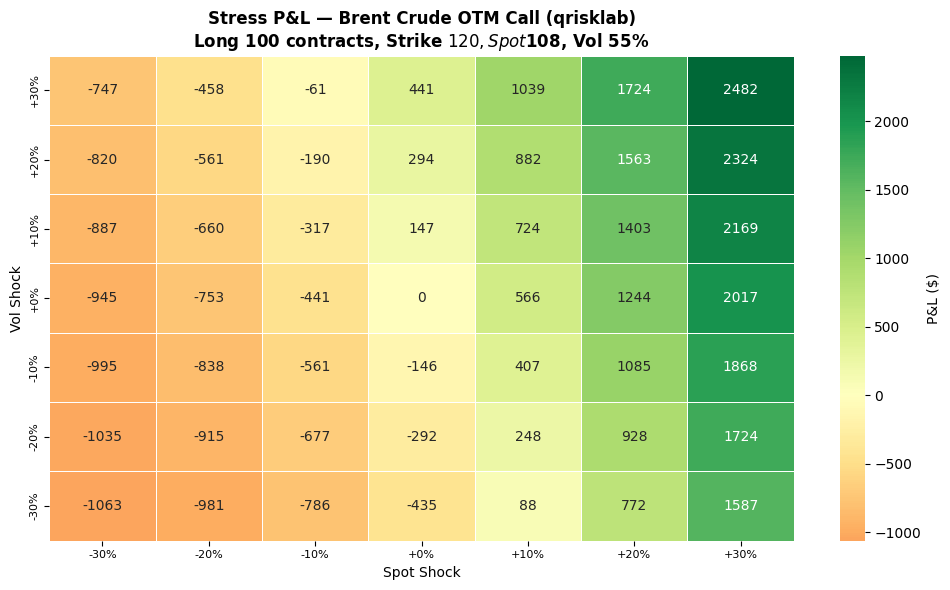

In [18]:
df_grid = pd.Series(grid).reset_index()
df_grid.columns = ['spot_shock', 'vol_shock', 'pnl']
heatmap = df_grid.pivot(index='vol_shock', columns='spot_shock', values='pnl').sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap,
    ax=ax,
    cmap='RdYlGn',
    center=0,
    annot=True,
    fmt='.0f',
    linewidths=0.4,
    cbar_kws={'label': 'P&L ($)'}
)
ax.set_title('Stress P&L — Brent Crude OTM Call (qrisklab)\nLong 100 contracts, Strike $120, Spot $108, Vol 55%', fontweight='bold')
ax.set_xlabel('Spot Shock')
ax.set_ylabel('Vol Shock')
ax.set_xticklabels([f'{float(x.get_text()):+.0%}' for x in ax.get_xticklabels()], fontsize=8)
ax.set_yticklabels([f'{float(y.get_text()):+.0%}' for y in ax.get_yticklabels()], fontsize=8)
plt.tight_layout()
plt.show()